In [1]:
# 표준 라이브러리
from pathlib import Path
import platform
from typing import List, Sequence, Any
import sys
import os

# 서드 파티 라이브러리
import pandas as pd
import numpy as np
from numpy.typing import ArrayLike

## 시각화 모듈
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.colors import Colormap
import seaborn as sns
import plotly.graph_objects as go

## 통계 모듈
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 머신러닝 모듈
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 로컬 모듈
sys.path.append(str(Path.cwd().parent))
sys.path.append(str(Path.cwd().parent / 'src'))
from src.plot import plot_box, plot_hist, plot_stacked_bar, plot_heatmap, plot_prop_bar, plot_mean_sem, plot_scatter_jitter
from src.utils import cramers_v, interpret_cramers_v, check_expected_frequencies, standardized_residuals
from src.utils import check_normality, check_homogeneity, calculate_eta_squared, calculate_epsilon_squared, perform_dunn_test, perform_gameshowell, perform_tukey_hsd

DATA_DIR = Path('../data/processed')

In [2]:
system = platform.system()

if system == 'Windows':
    # Windows: 맑은 고딕 사용
    plt.rcParams['font.family'] = 'Malgun Gothic'
    
elif system == 'Darwin':  # Darwin = macOS
    # macOS: 애플 고딕 사용
    plt.rcParams['font.family'] = 'AppleGothic'
    
elif system == 'Linux':
    # Linux: 나눔 고딕 사용 (사전 설치 필요)
    # 터미널: sudo apt-get install -y fonts-nanum
    plt.rcParams['font.family'] = 'NanumGothic'
    
else:
    print(f"알 수 없는 OS: {system}")

# 모든 OS 공통: 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print(f"OS: {system}, 설정된 폰트: {plt.rcParams['font.family']}")

OS: Linux, 설정된 폰트: ['NanumGothic']


In [3]:
pandas_kwargs = {
    'parse_dates': ['purchase_time', 'approved_time', 'carrier_delivered_time', 'delivered_time', 'estimated_delivery_time'],
    'date_format': '%Y-%m-%d %H:%M:%S',
    'memory_map': True
}

processed_data: pd.DataFrame = pd.read_csv(DATA_DIR / 'processed_data.csv', **pandas_kwargs)
processed_data

,category,review_score,quantity,price,freight_value,total_price,purchase_time,approved_time,carrier_delivered_time,delivered_time,...,customer_unique_id,order_id,product_id,payment_sequential,seller_id,zip_code_sell,city_sell,state_sell,latitude_sell,longitude_sell
0,가구·인테리어,4.0,1,124.99,21.88,NaN,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,...,861eff4711a542e4b93843c6dd7febb0,00e7ee1b050b8499577073aeb2a297a1,a9516a079e37a9c9c36b9b78b10169e8,1,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
1,생활용품,5.0,1,289.00,46.48,NaN,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,...,290c77bc529b7ac935b93aa66c333dc3,29150127e6685892b6eab3eec79f59c7,4aa6014eceb682077f9dc4bffebc05b0,1,b8bc237ba3788b23da09c0f1f3a3288c,88303,itajai,SC,-26.920912,-48.684937
2,가구·인테리어,5.0,1,139.94,17.79,NaN,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,...,060e732b5b29e8181a18229c7b0b2b5e,b2059ed67ce144a36e2aa97d2c9e9ad2,bd07b66896d6f1494f5b86251848ced7,1,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
3,가구·인테리어,5.0,1,149.94,23.36,NaN,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,...,259dac757896d24d7702b9acbbff3f3c,951670f92359f4fe4a63112aa7306eba,a5647c44af977b148e0a3a4751a09e2e,1,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
4,가구·인테리어,5.0,1,230.00,22.25,NaN,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,...,345ecd01c38d18a9036ed96c73b8d066,6b7d50bd145f6fc7f33cebabd7e49d0f,9391a573abe00141c56e38d84d7d5b3b,1,4a3ca9315b744ce9f8e9374361493884,14940,ibitinga,SP,-21.774868,-48.847152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101116,도서·미디어,4.0,1,74.90,13.88,NaN,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,...,1a29b476fee25c95fbafc67c5ac95cf8,6760e20addcf0121e9d58f2f1ff14298,ccb4503d9d43d245d3b295d0544f988b,1,527801b552d0077ffd170872eb49683b,17400,garca,SP,-22.210402,-49.662731
101117,스포츠·레저,5.0,1,114.90,14.16,NaN,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,...,d52a67c98be1cf6a5c84435bd38d095d,9ec0c8947d973db4f4e8dcf1fbfa8f1b,9ede6b0570a75a4b9de4f383329f99ee,1,3fd1e727ba94cfe122d165e176ce7967,14802,araraquara,SP,-21.775406,-48.168105
101118,건강·뷰티,1.0,1,37.00,19.04,NaN,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,...,e9f50caf99f032f0bf3c55141f019d99,fed4434add09a6f332ea398efd656a5c,7a5d2e1e131a860ae7d18f6fffa9d689,1,d9e7e7778b32987280a6f2cb9a39c57d,3304,sao paulo,SP,-23.545397,-46.581221
101119,패션·의류,5.0,1,689.00,22.07,NaN,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,...,73c2643a0a458b49f58cea58833b192e,e31ec91cea1ecf97797787471f98a8c2,f819f0c84a64f02d3a5606ca95edd272,1,4869f7a5dfa277a7dca6462dcf3b52b2,14840,guariba,SP,-21.369332,-48.225907


In [4]:
processed_data.columns

Index(['category', 'review_score', 'quantity', 'price', 'freight_value',
       'total_price', 'purchase_time', 'approved_time',
       'carrier_delivered_time', 'delivered_time', 'estimated_delivery_time',
       'payment_type', 'payment_installments', 'content_length', 'photos_qty',
       'weight_g', 'zip_code_cust', 'latitude_cust', 'longitude_cust',
       'city_cust', 'state_cust', 'customer_id', 'customer_unique_id',
       'order_id', 'product_id', 'payment_sequential', 'seller_id',
       'zip_code_sell', 'city_sell', 'state_sell', 'latitude_sell',
       'longitude_sell'],
      dtype='object')

## 파생변수 생성 - 시간

In [5]:
processed_data['delivered_days'] = (processed_data['delivered_time'] - processed_data['purchase_time']).dt.days
processed_data['approved_hours'] = ((processed_data['approved_time'] - processed_data['purchase_time']).dt.total_seconds() / 3600).round()
processed_data['delayed_days'] = (processed_data['delivered_time'] - processed_data['estimated_delivery_time']).dt.days

In [6]:
processed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101121 entries, 0 to 101120
Data columns (total 35 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   category                 101121 non-null  object        
 1   review_score             101121 non-null  object        
 2   quantity                 101121 non-null  int64         
 3   price                    101121 non-null  float64       
 4   freight_value            101121 non-null  float64       
 5   total_price              0 non-null       float64       
 6   purchase_time            101121 non-null  datetime64[ns]
 7   approved_time            101121 non-null  datetime64[ns]
 8   carrier_delivered_time   101121 non-null  datetime64[ns]
 9   delivered_time           101121 non-null  datetime64[ns]
 10  estimated_delivery_time  101121 non-null  datetime64[ns]
 11  payment_type             101121 non-null  object        
 12  payment_installm

In [7]:
review_data = processed_data[processed_data['review_score'] != '리뷰없음']
review_data = review_data.astype({
    'category': 'category',
    'review_score': float
})

In [8]:
seller_group = review_data.groupby(['seller_id'], observed=True, as_index=False)

seller_data = seller_group.agg(
    평균리뷰점수 = ('review_score', 'mean'),
    주문건수 = ('order_id', 'nunique'),
    판매량 = ('order_id', 'count'),
    평균승인시간 = ('approved_hours', 'mean'),
    평균배송일 = ('delivered_days', 'mean'),
    평균지연일 = ('delayed_days', 'mean'),
    평균내용길이 = ('content_length', 'mean'),
    평균사진개수 = ('photos_qty', 'mean'),
    도시 = ('city_sell', pd.Series.mode),
    주 = ('state_sell', pd.Series.mode)
)

In [9]:
seller_data.sort_values(['주문건수', '평균리뷰점수'], ascending=[False, False])

,seller_id,평균리뷰점수,주문건수,판매량,평균승인시간,평균배송일,평균지연일,평균내용길이,평균사진개수,도시,주
1175,6560211a19b47992c3666cc44a7e94c0,3.937792,1774,1929,9.691550,8.982893,-11.772421,382.918611,4.266978,sao paulo,SP
848,4a3ca9315b744ce9f8e9374361493884,3.797800,1722,1909,9.827658,13.755369,-9.831849,335.308539,1.169722,ibitinga,SP
2355,cc419e0650a3c5ba77189a1882b7556a,4.138753,1617,1636,11.236553,11.020782,-13.100244,840.784230,1.919927,santo andre,SP
355,1f50f920176fa81dab994f9023523100,4.086721,1371,1476,13.091463,14.982385,-10.779810,362.203252,2.016938,sao jose do rio preto,SP
2508,da8622b14eb17ae2831f4ac5b9dab84a,4.059310,1285,1450,11.357931,10.639310,-11.369655,255.908966,1.030345,piracicaba,SP
...,...,...,...,...,...,...,...,...,...,...,...
2525,dc120d932ddf9d4dfb6fd68beefda622,1.000000,1,2,0.000000,14.000000,-6.000000,1093.500000,3.000000,sao jose dos pinhais,PR
2562,df683dfda87bf71ac3fc63063fba369d,1.000000,1,1,0.000000,189.000000,167.000000,966.000000,3.000000,farroupilha,RS
2759,f114dca2828bf718548db175ebe2cfcd,1.000000,1,1,0.000000,10.000000,-22.000000,438.000000,1.000000,cambe,PR
2812,f524ad65d7e0f1daab730ef2d2e86196,1.000000,1,1,0.000000,24.000000,3.000000,595.000000,1.000000,soledade,RS


## 신뢰도 필터링

In [10]:
cnt_threshold = 5
filtered_seller = seller_data[seller_data['주문건수'] >= cnt_threshold]
filtered_seller.shape[0] / seller_data.shape[0] * 100

59.4059405940594

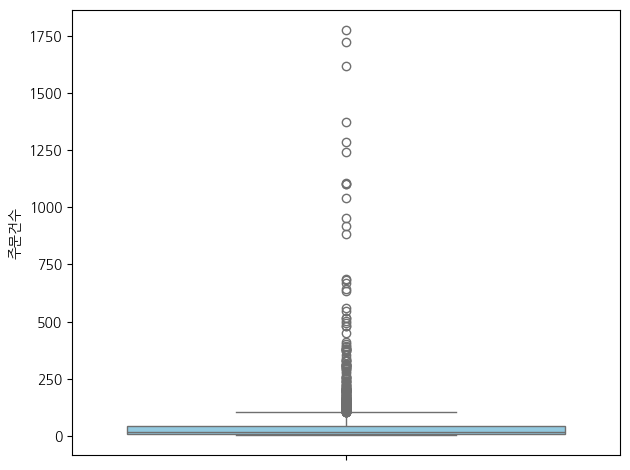

In [11]:
sns.boxplot(filtered_seller, y='주문건수', color='skyblue')
plt.tight_layout()
plt.show()

In [12]:
# 이상치 제거
# filtered_seller = filtered_seller[filtered_seller['평균지연일'] > -40]

In [13]:
vars = ['평균승인시간', '평균배송일', '평균지연일', '평균내용길이', '평균사진개수']

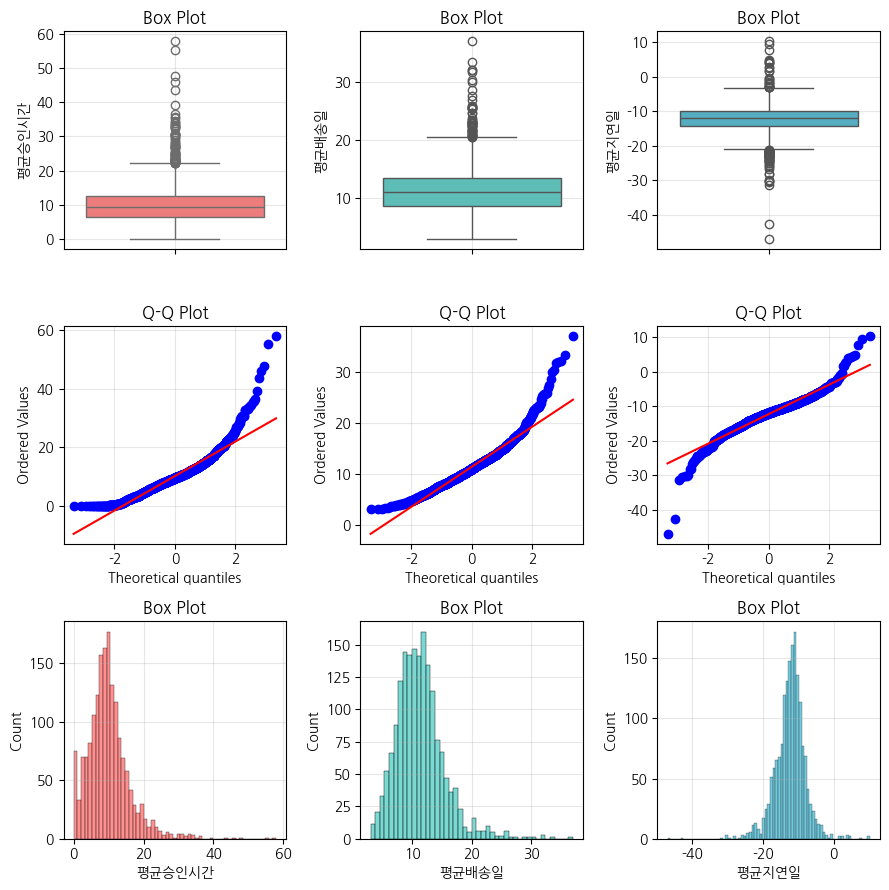

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

sns.boxplot(filtered_seller, y='평균승인시간', color='#FF6B6B', ax=axes[0][0])
axes[0][0].set_title('Box Plot')
axes[0][0].grid(True, alpha=0.3)
sns.boxplot(filtered_seller, y='평균배송일', color='#4ECDC4', ax=axes[0][1])
axes[0][1].set_title('Box Plot')
axes[0][1].grid(True, alpha=0.3)
sns.boxplot(filtered_seller, y='평균지연일', color='#45B7D1', ax=axes[0][2])
axes[0][2].set_title('Box Plot')
axes[0][2].grid(True, alpha=0.3)

stats.probplot(filtered_seller['평균승인시간'], dist="norm", plot=axes[1][0])
axes[1][0].set_title('Q-Q Plot')
axes[1][0].grid(True, alpha=0.3)
stats.probplot(filtered_seller['평균배송일'], dist="norm", plot=axes[1][1])
axes[1][1].set_title('Q-Q Plot')
axes[1][1].grid(True, alpha=0.3)
stats.probplot(filtered_seller['평균지연일'], dist="norm", plot=axes[1][2])
axes[1][2].set_title('Q-Q Plot')
axes[1][2].grid(True, alpha=0.3)


sns.histplot(filtered_seller, x='평균승인시간', color='#FF6B6B', ax=axes[2][0])
axes[2][0].set_title('Box Plot')
axes[2][0].grid(True, alpha=0.3)
sns.histplot(filtered_seller, x='평균배송일', color='#4ECDC4', ax=axes[2][1])
axes[2][1].set_title('Box Plot')
axes[2][1].grid(True, alpha=0.3)
sns.histplot(filtered_seller, x='평균지연일', color='#45B7D1', ax=axes[2][2])
axes[2][2].set_title('Box Plot')
axes[2][2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

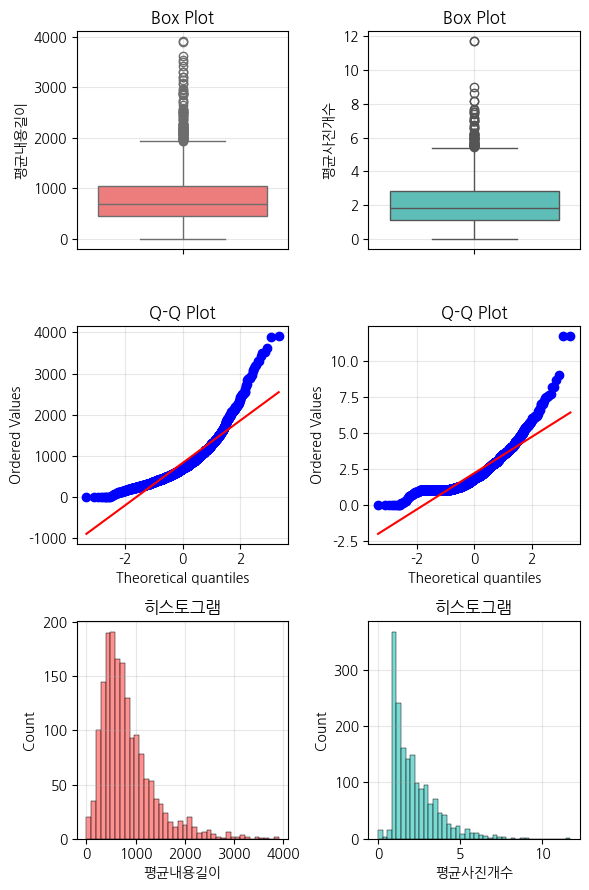

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(6, 9))

sns.boxplot(filtered_seller, y='평균내용길이', color='#FF6B6B', ax=axes[0][0])
axes[0][0].set_title('Box Plot')
axes[0][0].grid(True, alpha=0.3)
sns.boxplot(filtered_seller, y='평균사진개수', color='#4ECDC4', ax=axes[0][1])
axes[0][1].set_title('Box Plot')
axes[0][1].grid(True, alpha=0.3)

stats.probplot(filtered_seller['평균내용길이'], dist="norm", plot=axes[1][0])
axes[1][0].set_title('Q-Q Plot')
axes[1][0].grid(True, alpha=0.3)
stats.probplot(filtered_seller['평균사진개수'], dist="norm", plot=axes[1][1])
axes[1][1].set_title('Q-Q Plot')
axes[1][1].grid(True, alpha=0.3)


sns.histplot(filtered_seller, x='평균내용길이', color='#FF6B6B', ax=axes[2][0])
axes[2][0].set_title('히스토그램')
axes[2][0].grid(True, alpha=0.3)
sns.histplot(filtered_seller, x='평균사진개수', color='#4ECDC4', ax=axes[2][1])
axes[2][1].set_title('히스토그램')
axes[2][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 다중공선성 확인

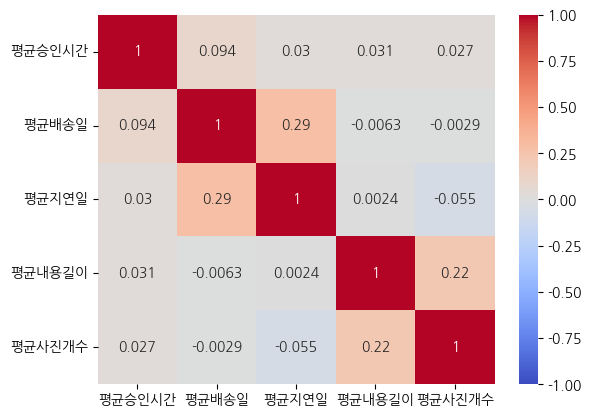

In [16]:
df_corr = filtered_seller[vars].copy()
corr = df_corr.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

In [17]:
X = filtered_seller[vars].copy()

# 상수항 추가
X = sm.add_constant(X)

# VIF 계산
vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df)

  variable        VIF
0    const  28.397325
1   평균승인시간   1.010321
2    평균배송일   1.098404
3    평균지연일   1.093284
4   평균내용길이   1.053501
5   평균사진개수   1.056530


In [18]:
# ========================================
# 1. 데이터 준비
# ========================================

# 군집화에 사용할 변수 선택 (5개)

X = filtered_seller[vars].copy()

print(f"분석 대상 판매자 수: {len(X)}")
print(f"사용 변수: {vars}")

# ========================================
# 2. 데이터 표준화
# ========================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DataFrame으로 변환 (나중에 편리함)
X_scaled_df = pd.DataFrame(X_scaled, columns=vars, index=X.index)


# ========================================
# 3. 최적 k 값 탐색
# ========================================

k_range = range(2, 9)  # k=2~8 테스트
inertia_list = []
silhouette_list = []
kmeans_models = {}

for k in k_range:
    # K-means 수행
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # 성능 지표 계산
    inertia = kmeans.inertia_  # 군집 내 분산 (낮을수록 좋음)
    silhouette = silhouette_score(X_scaled, labels)  # -1~1 (높을수록 좋음)
    
    inertia_list.append(inertia)
    silhouette_list.append(silhouette)
    kmeans_models[k] = kmeans
    
    print(f"k={k} | Inertia: {inertia:.2f} | Silhouette: {silhouette:.3f}")


# ========================================
# 4. Elbow & Silhouette 차트
# ========================================

from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Elbow Method", "Silhouette Score"),
    specs=[[{"secondary_y": False}, {"secondary_y": False}]]
)

# Elbow Plot
fig.add_trace(
    go.Scatter(
        x=list(k_range), y=inertia_list,
        mode='lines+markers',
        name='Inertia',
        marker=dict(size=8)
    ),
    row=1, col=1
)

# Silhouette Plot
fig.add_trace(
    go.Scatter(
        x=list(k_range), y=silhouette_list,
        mode='lines+markers',
        name='Silhouette',
        marker=dict(size=8, color='coral')
    ),
    row=1, col=2
)

fig.update_xaxes(title_text="Number of Clusters (k)", row=1, col=1)
fig.update_xaxes(title_text="Number of Clusters (k)", row=1, col=2)
fig.update_yaxes(title_text="Inertia", row=1, col=1)
fig.update_yaxes(title_text="Silhouette Score", row=1, col=2)

fig.update_layout(
    title="Optimal k Selection",
    template="plotly_white",
    height=400
)

fig.show()

분석 대상 판매자 수: 1740
사용 변수: ['평균승인시간', '평균배송일', '평균지연일', '평균내용길이', '평균사진개수']
k=2 | Inertia: 7386.10 | Silhouette: 0.215
k=3 | Inertia: 6351.25 | Silhouette: 0.178
k=4 | Inertia: 5666.48 | Silhouette: 0.181
k=5 | Inertia: 5031.10 | Silhouette: 0.201
k=6 | Inertia: 4566.92 | Silhouette: 0.183
k=7 | Inertia: 4251.43 | Silhouette: 0.167
k=8 | Inertia: 4008.49 | Silhouette: 0.173


In [19]:
# ========================================
# 5. 최종 k 선택 및 군집화
# ========================================

# 시각적으로 elbow 지점 확인 후 선택
optimal_k = 3  # 예시: k=3 선택

kmeans_final = kmeans_models[optimal_k]
filtered_seller.loc[:, 'cluster'] = kmeans_final.labels_

print(f"\n✅ 최종 군집 수: {optimal_k}")
print(f"군집별 판매자 수:\n{filtered_seller['cluster'].value_counts().sort_index()}")


# ========================================
# 6. 군집 프로파일링
# ========================================

# 군집별 평균값 (원본 스케일)
cluster_profile = filtered_seller.groupby('cluster')[vars].mean()

# 추가: 평점도 확인
cluster_profile['평균리뷰점수'] = filtered_seller.groupby('cluster')['평균리뷰점수'].mean()
cluster_profile['주문건수'] = filtered_seller.groupby('cluster').size()

print("\n📊 군집별 평균 프로파일:")
print(cluster_profile.round(2))


# ========================================
# 7. 2차원 시각화 (PCA)
# ========================================

# 5차원 → 2차원 축소
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# DataFrame으로 변환
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=X.index)
pca_df['cluster'] = filtered_seller['cluster']
pca_df['review_score'] = filtered_seller['평균리뷰점수']

# Plotly 산점도
fig = go.Figure()

for cluster_id in range(optimal_k):
    cluster_data = pca_df[pca_df['cluster'] == cluster_id]
    
    fig.add_trace(
        go.Scatter(
            x=cluster_data['PC1'],
            y=cluster_data['PC2'],
            mode='markers',
            name=f'Cluster {cluster_id}',
            marker=dict(
                size=8,
                opacity=0.7,
                line=dict(width=0.5, color='white')
            ),
            text=cluster_data['review_score'].round(2),
            hovertemplate='PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>평점: %{text}<extra></extra>'
        )
    )

# 군집 중심 표시
centers_pca = pca.transform(kmeans_final.cluster_centers_)
fig.add_trace(
    go.Scatter(
        x=centers_pca[:, 0],
        y=centers_pca[:, 1],
        mode='markers',
        name='Centroids',
        marker=dict(
            symbol='x',
            size=20,
            color='black',
            line=dict(width=2)
        )
    )
)

fig.update_layout(
    title=f"판매자 군집 (k={optimal_k}) - PCA 2D Projection<br><sub>설명력: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}</sub>",
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()


# ========================================
# 8. 레이더 차트 (군집 비교)
# ========================================

# 표준화된 값으로 비교 (0-1 스케일)
from sklearn.preprocessing import MinMaxScaler

scaler_viz = MinMaxScaler()
cluster_profile_scaled = pd.DataFrame(
    scaler_viz.fit_transform(cluster_profile[vars]),
    columns=vars,
    index=cluster_profile.index
)

fig = go.Figure()

for cluster_id in cluster_profile_scaled.index:
    values = cluster_profile_scaled.loc[cluster_id].tolist()
    values.append(values[0])  # 원형 완성
    
    fig.add_trace(
        go.Scatterpolar(
            r=values,
            theta=vars + [vars[0]],
            fill='toself',
            name=f'Cluster {cluster_id}'
        )
    )

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )
    ),
    title=f"군집별 특성 비교 (k={optimal_k})",
    template="plotly_white"
)

fig.show()


✅ 최종 군집 수: 3
군집별 판매자 수:
cluster
0    920
1    365
2    455
Name: count, dtype: int64

📊 군집별 평균 프로파일:
         평균승인시간  평균배송일  평균지연일   평균내용길이  평균사진개수  평균리뷰점수  주문건수
cluster                                                     
0          9.07   9.47 -13.71   659.08    1.72    4.23   920
1         10.05  10.72 -12.81  1450.96    3.78    4.23   365
2         12.13  15.66  -9.12   683.75    1.87    3.90   455


/tmp/ipykernel_602364/2561716102.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [20]:
filtered_seller.head(10) 

,seller_id,평균리뷰점수,주문건수,판매량,평균승인시간,평균배송일,평균지연일,평균내용길이,평균사진개수,도시,주,cluster
1,001cca7ae9ae17fb1caed9dfb1094831,4.025907,191,193,10.259067,12.652850,-13.305699,477.424870,1.740933,cariacica,ES,0
2,002100f778ceb8431b7a1020ff7ab48f,4.000000,50,56,21.821429,15.696429,-8.428571,666.089286,1.053571,franca,SP,2
4,004c9cd9d87a3c30c522c48c4fc07416,4.150327,149,153,8.163399,14.104575,-11.679739,486.169935,0.967320,ibitinga,SP,2
5,00720abe85ba0859807595bbf045a33b,3.625000,13,16,4.687500,9.875000,-10.562500,477.125000,2.125000,guarulhos,SP,0
8,00ee68308b45bc5e2660cd833c3f81cc,4.277372,129,137,11.759124,8.861314,-11.306569,543.430657,1.094891,sao paulo,SP,0
9,00fc707aaaad2d31347cf883cd2dfe10,3.982143,102,112,9.258929,14.625000,-15.848214,555.910714,1.000000,maringa,PR,0
13,013900e863eace745d3ec7614cab5b1a,4.730769,23,26,3.461538,11.038462,-16.115385,753.461538,3.538462,curitiba,PR,0
14,014c0679dd340a0e338872e7ec85666a,4.000000,12,12,6.166667,19.250000,-10.750000,1496.916667,3.000000,timoteo,MG,2
15,014d9a685fd57276679edd00e07089e5,3.125000,11,16,6.000000,8.812500,-16.250000,1023.562500,2.250000,maringa,PR,0
16,0176f73cc1195f367f7b32db1e5b3aa8,3.975000,37,40,9.600000,12.575000,-9.025000,389.550000,1.100000,ibitinga,SP,2


In [21]:
# 군집 중심값 추출 (표준화된 스케일)
centers_scaled = kmeans_final.cluster_centers_

# DataFrame으로 변환
centers_df = pd.DataFrame(
    centers_scaled,
    columns=vars,
    index=[f'Cluster {i}' for i in range(optimal_k)]
)

print("📍 군집 중심 (표준화된 값):")
print(centers_df.round(3))



def explain_cluster_assignment(seller_id, seller_data, kmeans_model, scaler, feature_columns):
    """
    특정 판매자가 왜 해당 군집에 배정되었는지 설명
    """
    # 판매자 데이터 추출
    seller = seller_data[seller_data['seller_id'] == seller_id]
    seller_features = seller[feature_columns].values[0]
    seller_cluster = seller['cluster'].values[0]
    
    # 표준화
    seller_scaled = scaler.transform([seller_features])[0]
    
    # 각 군집 중심까지 거리 계산
    centers = kmeans_model.cluster_centers_
    distances = {}
    
    for i, center in enumerate(centers):
        dist = np.sqrt(np.sum((seller_scaled - center) ** 2))
        distances[i] = dist
    
    # 결과 출력
    print(f"🔍 판매자 {seller_id} 분석")
    print(f"   배정된 군집: Cluster {seller_cluster}")
    print(f"\n📏 각 군집 중심까지의 거리:")
    
    for cluster_id, dist in sorted(distances.items(), key=lambda x: x[1]):
        marker = "✅ 배정됨" if cluster_id == seller_cluster else ""
        print(f"   Cluster {cluster_id}: {dist:.3f} {marker}")
    
    # 차원별 기여도 분석
    assigned_center = centers[seller_cluster]
    dim_contributions = (seller_scaled - assigned_center) ** 2
    
    print(f"\n📊 배정 이유 (차원별 기여도):")
    contributions_df = pd.DataFrame({
        '변수': feature_columns,
        '판매자값(표준화)': seller_scaled,
        '중심값(표준화)': assigned_center,
        '거리제곱': dim_contributions,
        '기여도(%)': dim_contributions / dim_contributions.sum() * 100
    })
    
    contributions_df = contributions_df.sort_values('기여도(%)', ascending=False)
    print(contributions_df.to_string(index=False))
    
    # 해석
    top_feature = contributions_df.iloc[0]['변수']
    top_contribution = contributions_df.iloc[0]['기여도(%)']
    
    print(f"\n💡 핵심 이유: '{top_feature}'가 이 군집과 가장 유사 (기여도 {top_contribution:.1f}%)")
    
    return contributions_df

# 사용 예시
explain_cluster_assignment(
    seller_id='da8622b14eb17ae2831f4ac5b9dab84a',  # 분석할 판매자 ID
    seller_data=filtered_seller,
    kmeans_model=kmeans_final,
    scaler=scaler,
    feature_columns=vars
)



def analyze_cluster_importance(kmeans_model, feature_columns):
    """
    어떤 변수가 군집 구분에 가장 중요했는지 분석
    """
    centers = kmeans_model.cluster_centers_
    
    # 군집 간 중심 거리 (변수별)
    # 중심들 간 표준편차 = 군집 분리에 얼마나 기여했는지
    
    importance = {}
    for i, feature in enumerate(feature_columns):
        # 각 변수 차원에서 군집 중심들의 표준편차
        center_values = centers[:, i]
        std = np.std(center_values)
        importance[feature] = std
    
    # 정규화 (합 = 100%)
    total = sum(importance.values())
    importance_pct = {k: v/total*100 for k, v in importance.items()}
    
    # DataFrame으로 정리
    importance_df = pd.DataFrame({
        '변수': importance_pct.keys(),
        '중요도(%)': importance_pct.values()
    }).sort_values('중요도(%)', ascending=False)
    
    print("📊 군집 구분에 중요한 변수 순위:")
    print(importance_df.to_string(index=False))
    
    # 시각화
    import plotly.express as px
    fig = px.bar(
        importance_df, 
        x='변수', 
        y='중요도(%)',
        title='K-means 군집화 변수 중요도',
        text='중요도(%)'
    )
    fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
    fig.show()
    
    return importance_df

# 실행
importance_df = analyze_cluster_importance(kmeans_final, vars)

📍 군집 중심 (표준화된 값):
           평균승인시간  평균배송일  평균지연일  평균내용길이  평균사진개수
Cluster 0  -0.162 -0.465 -0.317  -0.313  -0.346
Cluster 1  -0.004 -0.156 -0.111   1.124   1.163
Cluster 2   0.331  1.064  0.731  -0.268  -0.233
🔍 판매자 da8622b14eb17ae2831f4ac5b9dab84a 분석
   배정된 군집: Cluster 0

📏 각 군집 중심까지의 거리:
   Cluster 0: 1.139 ✅ 배정됨
   Cluster 2: 1.674 
   Cluster 1: 2.986 

📊 배정 이유 (차원별 기여도):
    변수  판매자값(표준화)  중심값(표준화)     거리제곱    기여도(%)
평균내용길이  -1.044834 -0.313167 0.535336 41.273824
 평균지연일   0.216853 -0.317283 0.285302 21.996446
평균사진개수  -0.851969 -0.345824 0.256183 19.751399
평균승인시간   0.207555 -0.162241 0.136749 10.543217
 평균배송일  -0.175602 -0.464506 0.083466  6.435115

💡 핵심 이유: '평균내용길이'가 이 군집과 가장 유사 (기여도 41.3%)
📊 군집 구분에 중요한 변수 순위:
    변수    중요도(%)
평균사진개수 25.676719
평균내용길이 24.966679
 평균배송일 24.694332
 평균지연일 16.959610
평균승인시간  7.702660


/home/yeeun/anaconda3/envs/sparta-project2/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



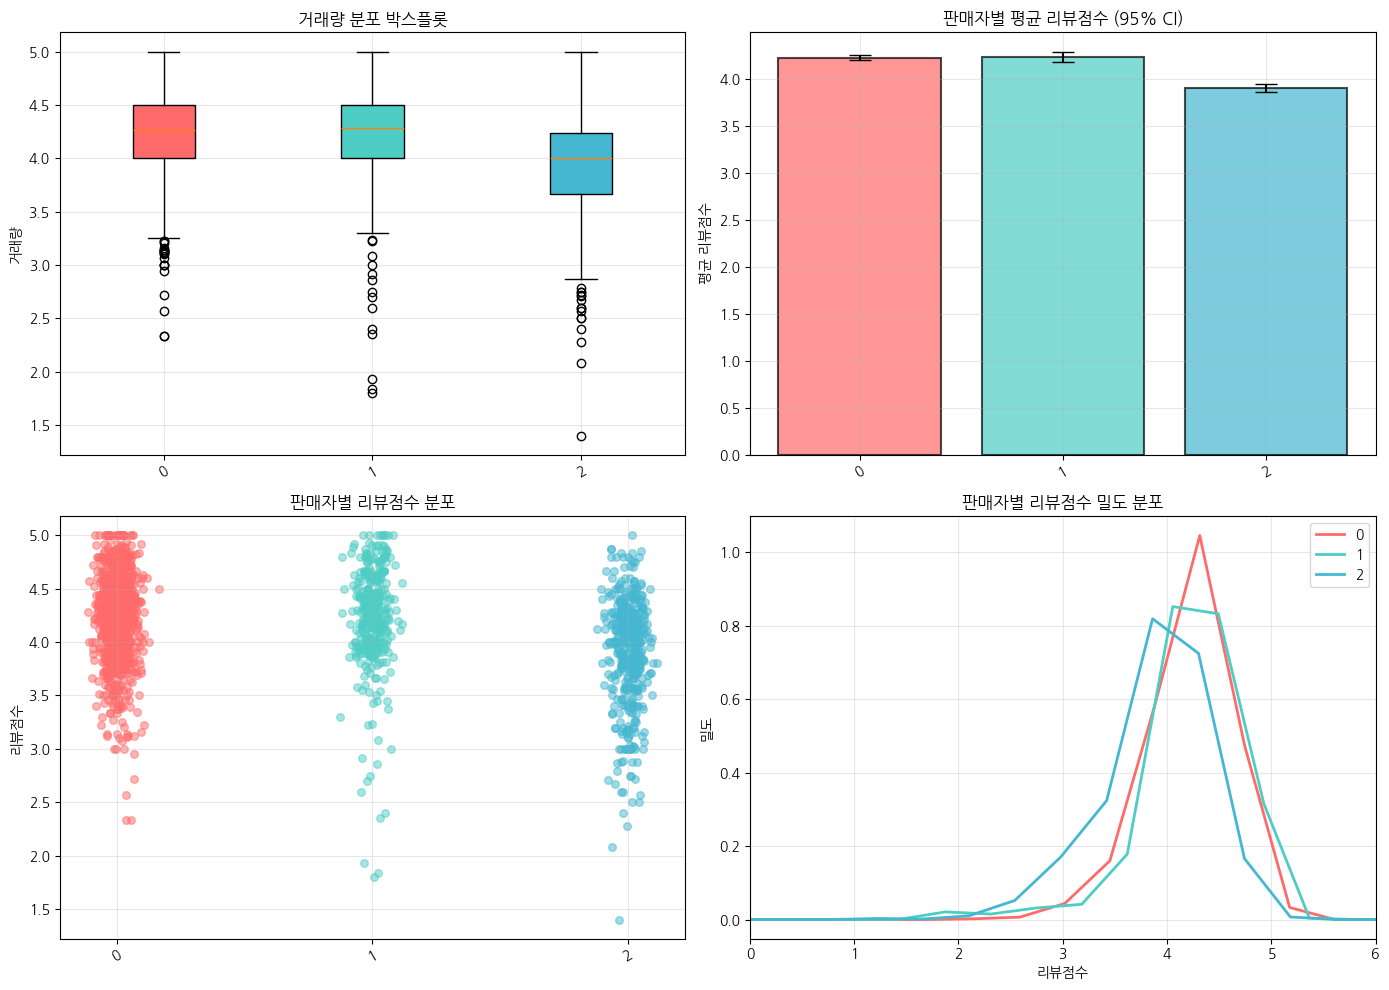


[일원배치 ANOVA]
--------------------------------------------------
H₀: 판매자마다 평균 리뷰점수 모두 같다
H₁: 적어도 한 판매자의 평균리뷰점수 다르다
유의수준: α = 0.05

[정규성 검정 - Shapiro-Wilk Test]
--------------------------------------------------
   그룹   W-통계량  p-value      판정
0   0  0.9746      0.0  정규분포 X
1   1  0.8829      0.0  정규분포 X
2   2  0.9563      0.0  정규분포 X

⚠️ 일부 그룹이 정규성 가정을 만족하지 않습니다.
   → 비모수 검정(Kruskal-Wallis) 고려

[등분산성 검정 - Levene's Test]
--------------------------------------------------
Levene 통계량: 5.0988
p-value: 0.0062
⚠️ 등분산성 가정을 만족하지 않습니다.
   → Welch's ANOVA 또는 Games-Howell 사후검정 권장

[ANOVA 검정 결과]
--------------------------------------------------
⚠️ 정규성 가정이 위반되었으므로 비모수 검정을 수행합니다.

[Kruskal-Wallis 검정 (비모수 검정)]
\- Kruskal-Wallis 검정은 또한 등분산성 가정이 필요 없음
--------------------------------------------------
H-통계량: 161.0456
자유도: 2
p-value: 0.000000
효과 크기 (ε²): 0.0916 (중간 효과)
   → 판매자 차이가 전체 리뷰점수 변동의 9.2% 설명

[검정 결론]
✅ p-value(0.000000) < 0.05 → 귀무가설 기각
   판매자별 리뷰점수에 유의한 차이가 있음


In [ ]:

# ========================================
# 9. 통계 검증 (군집 간 평점 차이)
# ========================================

filtered_seller.loc[:, 'cluster'] = filtered_seller['cluster'].astype('category')
labels = filtered_seller['cluster'].cat.categories.tolist()
anova_data = [filtered_seller[filtered_seller['cluster'] == i]['평균리뷰점수'] for i in labels]

# 색상 목록 정의 (RGB 튜플 또는 16진수 코드 사용)
cluster_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

review_colormap = 'hot'

var1 = '판매자'
var2 = '리뷰점수'
label = '거래량'

clusters = [filtered_seller[filtered_seller['cluster'] == i]['평균리뷰점수'].values 
            for i in range(optimal_k)]

fig = plt.figure(figsize=(14, 10))
ax1 = plt.subplot(2, 2, 1)

# 박스플롯

plot_box(ax1, clusters, tick_labels=labels, ylabel=label, color=cluster_colors, xrotation=30)

# 평균 및 오차막대
ax2 = plt.subplot(2, 2, 2)
plot_mean_sem(clusters, ax2, var1, var2, labels, cluster_colors, 30)

# 산점도 with jitter
ax3 = plt.subplot(2, 2, 3)
plot_scatter_jitter(clusters, ax3, var1, var2, labels, cluster_colors, xrotation=30)

# 밀도 플롯
ax4 = plt.subplot(2, 2, 4)
for label, data, color in zip(labels, clusters, cluster_colors):
    density = stats.gaussian_kde(data)
    x_range = np.linspace(data.min() - 20, data.max() + 20, 100)
    ax4.plot(x_range, density(x_range), label=label, color=color, linewidth=2)
ax4.set_title(f'{var1}별 {var2} 밀도 분포')
ax4.set_xlabel(var2)
ax4.set_ylabel('밀도')
ax4.set_xlim(0, 6)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# =============================================================================
# ANOVA 분석 수행
# =============================================================================
print("\n[일원배치 ANOVA]")
print("-"*50)

print(f"H₀: {var1}마다 평균 {var2} 모두 같다")
print(f"H₁: 적어도 한 {var1}의 평균{var2} 다르다")
print("유의수준: α = 0.05")

# -----------------------------------------------------------------------------
# 1. ANOVA 가정 검정
# -----------------------------------------------------------------------------
is_normal = check_normality(clusters, labels)
is_equal_var = check_homogeneity(clusters, labels)

# -----------------------------------------------------------------------------
# 2. ANOVA 수행 (정규성 위반 시 Kruskal-Wallis 고려)
# -----------------------------------------------------------------------------
print("\n[ANOVA 검정 결과]")
print("-"*50)

if not is_normal:
    print("⚠️ 정규성 가정이 위반되었으므로 비모수 검정을 수행합니다.")
    print("\n[Kruskal-Wallis 검정 (비모수 검정)]")
    print("\- Kruskal-Wallis 검정은 또한 등분산성 가정이 필요 없음")
    print("-"*50)
    h_stat, p_value = stats.kruskal(*clusters)
    
    # 자유도 및 효과 크기 계산
    k = len(clusters)
    N = sum(len(group) for group in clusters)
    df = k - 1
    
    # 비모수 효과 크기 계산
    epsilon_sq, effect_interpretation = calculate_epsilon_squared(h_stat, k, N)
    
    print(f"H-통계량: {h_stat:.4f}")
    print(f"자유도: {df}")
    print(f"p-value: {p_value:.6f}")
    print(f"효과 크기 (ε²): {epsilon_sq:.4f} ({effect_interpretation})")
    print(f"   → {var1} 차이가 전체 {var2} 변동의 {epsilon_sq*100:.1f}% 설명")
    
    # 결론
    print("\n[검정 결론]")
    if p_value < 0.05:
        print(f"✅ p-value({p_value:.6f}) < 0.05 → 귀무가설 기각")
        print(f"   {var1}별 {var2}에 유의한 차이가 있음")
    else:
        print(f"❌ p-value({p_value:.6f}) ≥ 0.05 → 귀무가설 채택")
        print(f"   {var1}별 {var2}에 유의한 차이가 없음")

# ========================================
# 10. 결과 저장
# ========================================

# 군집 라벨이 추가된 데이터 저장
clustered_seller = filtered_seller[['seller_id', 'cluster'] + vars + ['평균리뷰점수']]
# filtered_seller[['seller_id', 'cluster'] + vars + ['avg_review_score']].to_csv(
#     'seller_clusters.csv', index=False
# )

# print("\n✅ 분석 완료! seller_clusters.csv 저장됨")

In [ ]:
clustered_seller

In [ ]:
clustered_seller.info()

In [ ]:
review_group = lambda x: 0 if x < 4.2 else 1 if x < 4.75 else 2
clustered_seller = clustered_seller[clustered_seller['평균리뷰점수'] != 5]
clustered_seller.loc[:, '리뷰점수그룹'] = clustered_seller['평균리뷰점수'].map(review_group)
clustered_seller.head(10)

In [ ]:
clustered_seller['리뷰점수그룹'].value_counts()

## t-test

In [ ]:
cluster_review_data = clustered_seller.groupby(['cluster', '리뷰점수그룹'], observed=False).size().unstack()
cluster_review_data

In [ ]:
# 색상 목록 정의 (RGB 튜플 또는 16진수 코드 사용)
distance_colormap = 'cool'

review_colormap = 'hot'

var1 = '판매자'
var2 = '리뷰'
label = '고객수'


# 데이터 시각화
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# 누적 막대그래프
plot_stacked_bar(cluster_review_data, axes[0], var1, var2, label, cmap=distance_colormap)

# 히트맵 -> 비율 or 스케일링해서 보여주면 될 것 같다.
plot_heatmap(cluster_review_data, axes[1], var1, var2, label, normalize='column')


# 비율 막대그래프
plot_prop_bar(cluster_review_data, axes[2], var1, var2, cmap=review_colormap, xrotation=30)


plt.tight_layout()
plt.show()

In [ ]:
# 기대빈도 확인 (카이제곱 적절성 판단)
is_valid = check_expected_frequencies(cluster_review_data)

In [ ]:
# 적절한 검정 선택 및 수행 

print("\n[카이제곱 독립성 검정]")
print('-'*40)

alpha = 0.05

# 가설 설정
print(f"H₀: {var1} & {var2} - 독립적이다")
print(f"H₁: {var1} & {var2} - 관련이 있다")
print(f"유의수준: α = {alpha}")


chi2_stat, p_value, dof, expected = chi2_contingency(cluster_review_data)

print(f"\n카이제곱 통계량: {chi2_stat:.4f}")
print(f"자유도: {dof}")  # df = (행수-1) × (열수-1)
print(f"p-value: {p_value:.4f}")

In [ ]:
# 효과 크기 계산

n = cluster_review_data.values.sum()
r, c = cluster_review_data.shape
v = cramers_v(chi2_stat, n, r, c)

print(f"Cramér's V: {v:.3f} ({interpret_cramers_v(v)})")

In [ ]:
# 잔차 분석 또는 Odds 분석 (필요한 경우)

expected_df = pd.DataFrame(expected, 
                           index=cluster_review_data.index,
                           columns=cluster_review_data.columns)
print("\n[기대빈도]")
display(expected_df.round(2))


# 각 셀이 독립성 가정에서 얼마나 벗어났는지 측정
# 표준화 잔차 = (관측값 - 기대값) / sqrt(기대값)
std_residuals = standardized_residuals(cluster_review_data.values, expected)
residuals_df = pd.DataFrame(std_residuals,
                            index=cluster_review_data.index,
                            columns=cluster_review_data.columns)
print("\n[표준화 잔차]")
display(residuals_df.round(2))
print("(|잔차| > 2: 유의한 차이, |잔차| > 3: 매우 강한 연관성)")

In [ ]:
# 해석

print("\n[결론]")

# p-value를 유의수준과 비교하여 가설 채택/기각 결정
if p_value < 0.05:
    print(f"✅ p-value({p_value:.4f}) < 0.05 → 귀무가설 기각")
    print(f"   {var1} & {var2} - 관련이 있다")
    print(f"   효과 크기: {interpret_cramers_v(v)}")
    
    # -------------------------------------------------------------------------
    # 6. 사후 분석 (Post-hoc Analysis)
    # -------------------------------------------------------------------------
    # 표준화 잔차를 통해 어느 조합이 특히 연관성이 강한지 분석
    print("\n[구체적 패턴 분석]")
    print("   표준화 잔차 |값| > 2인 셀 해석:")
    
    for i, grade in enumerate(cluster_review_data.index):
        for j, lang in enumerate(cluster_review_data.columns):
            # |잔차| > 2: 해당 조합이 독립성에서 유의하게 벗어남
            if abs(std_residuals[i, j]) > 2:
                if std_residuals[i, j] > 0:
                    # 양수: 관측값 > 기대값 (과대 표현)
                    print(f"   • {grade} - {lang}: 예상보다 높음 (잔차={std_residuals[i, j]:.2f})")
                else:
                    # 음수: 관측값 < 기대값 (과소 표현)
                    print(f"   • {grade} - {lang}: 예상보다 낮음 (잔차={std_residuals[i, j]:.2f})")
else:
    print(f"❌ p-value({p_value:.4f}) ≥ 0.05 → 귀무가설 채택")
    print(f"   {var1} & {var2} - 독립적이다")
    print(f"   ({var1} -> {var2}에 영향을 주지 않음)")